# Bisection Method (July 14)
**NYIT High School Mathematics Research Enrichment Program**

The bisection method finds a root of $f(x) = 0$ on an interval $[a, b]$
where $f(a)$ and $f(b)$ have opposite signs (guaranteed by the Intermediate Value Theorem).

At each step, we evaluate $f$ at the midpoint $p = \frac{a+b}{2}$ and
replace whichever endpoint shares the same sign as $f(p)$,
halving the interval every iteration.

**Test problem:** find a root of $f(x) = (x+4)x^2 - 10$ on $[1, 2]$.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

## Inputs

In [4]:
# -------------- inputs -------------------
f = lambda x: (x + 4) * x * x - 10   # function whose root we seek
a = 1.0;  b = 2.0                     # initial interval [a, b]

# tolerance / max iterations
TOL = 1e-10
NI  = 50
# -----------------------------------------

# Machine epsilon (equivalent to MATLAB's eps)
EPS = sys.float_info.epsilon

# Quick sanity check: IVT requires f(a) and f(b) to have opposite signs
assert f(a) * f(b) < 0, "f(a) and f(b) must have opposite signs — check your interval!"
print(f"f({a}) = {f(a):.6f}")
print(f"f({b}) = {f(b):.6f}")
print("Signs are opposite ✓  —  a root exists in [{}, {}]".format(a, b))

f(1.0) = -5.000000
f(2.0) = 14.000000
Signs are opposite ✓  —  a root exists in [1.0, 2.0]


## Bisection Algorithm

In [5]:
# ---- STEP 1: initialization ----
i        = 1
fa       = f(a)
converge = False          # convergence flag

# Store history for the convergence table
history  = []             # each row: [i, a, b, p, f(p), (b-a)/2]

# ---- STEP 2: iteration ----
while i <= NI:

    # STEP 3: compute p at the i-th step
    p  = a + (b - a) / 2
    fp = f(p)

    history.append([i, a, b, p, fp, (b - a) / 2])

    # STEP 4: check if it meets the stopping criteria
    if abs(fp) < EPS or (b - a) / 2 < TOL:   # EPS = machine epsilon
        converge = True   # bisection method converged!
        break             # exit out of while loop

    else:
        # STEP 5
        i += 1

        # STEP 6
        if fa * fp > 0:
            a  = p;  fa = fp
        else:
            b  = p

# ---- Output ----
if converge:
    print(f"Bisection method converged in {i} iteration(s).")
else:
    print(f"Bisection method did NOT converge after {NI} iterations.")

print(f"Approximate root :  p  = {p:.10f}")
print(f"Residual         :  f(p) = {fp:.4e}")
print(f"Interval width   :  (b-a)/2 = {(b-a)/2:.4e}")

Bisection method converged in 34 iteration(s).
Approximate root :  p  = 1.3652300134
Residual         :  f(p) = 4.5681e-10
Interval width   :  (b-a)/2 = 5.8208e-11


## Convergence Table

Each row shows one bisection step: the current interval $[a,b]$,
the midpoint $p$, the residual $f(p)$, and the error bound $(b-a)/2$.

In [6]:
print(f"{'Iter':>4}  {'a':>12}  {'b':>12}  {'p':>14}  {'f(p)':>12}  {'(b-a)/2':>12}")
print("-" * 72)
for row in history:
    it, ai, bi, pi, fpi, half = row
    print(f"{int(it):>4}  {ai:>12.8f}  {bi:>12.8f}  {pi:>14.10f}  {fpi:>12.4e}  {half:>12.4e}")

Iter             a             b               p          f(p)       (b-a)/2
------------------------------------------------------------------------
   1    1.00000000    2.00000000    1.5000000000    2.3750e+00    5.0000e-01
   2    1.00000000    1.50000000    1.2500000000   -1.7969e+00    2.5000e-01
   3    1.25000000    1.50000000    1.3750000000    1.6211e-01    1.2500e-01
   4    1.25000000    1.37500000    1.3125000000   -8.4839e-01    6.2500e-02
   5    1.31250000    1.37500000    1.3437500000   -3.5098e-01    3.1250e-02
   6    1.34375000    1.37500000    1.3593750000   -9.6409e-02    1.5625e-02
   7    1.35937500    1.37500000    1.3671875000    3.2356e-02    7.8125e-03
   8    1.35937500    1.36718750    1.3632812500   -3.2150e-02    3.9062e-03
   9    1.36328125    1.36718750    1.3652343750    7.2025e-05    1.9531e-03
  10    1.36328125    1.36523438    1.3642578125   -1.6047e-02    9.7656e-04
  11    1.36425781    1.36523438    1.3647460938   -7.9893e-03    4.8828e-04
  1

## Visualization

### Plot 1 — Function and root

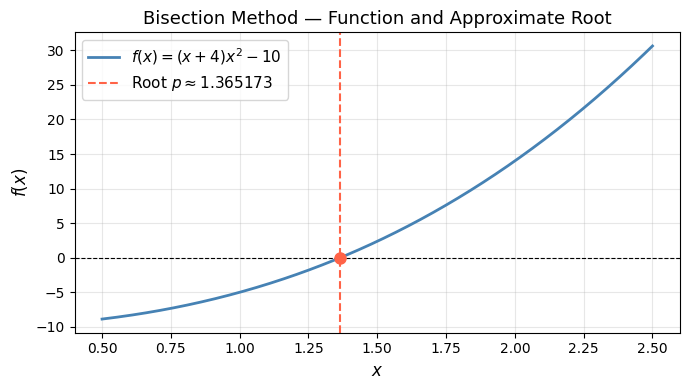

In [ ]:
x_vals = np.linspace(0.5, 2.5, 400)
y_vals = f(x_vals)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, y_vals, 'steelblue', linewidth=2, label=r'$f(x) = (x+4)x^2 - 10$')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(p, color='tomato', linewidth=1.5, linestyle='--', label=f'Root $p \\approx {p:.6f}$')
ax.plot(p, fp, 'o', color='tomato', markersize=8)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$f(x)$', fontsize=12)
ax.set_title('Bisection Method — Function and Approximate Root', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 2 — Convergence: error bound $(b-a)/2$ vs. iteration

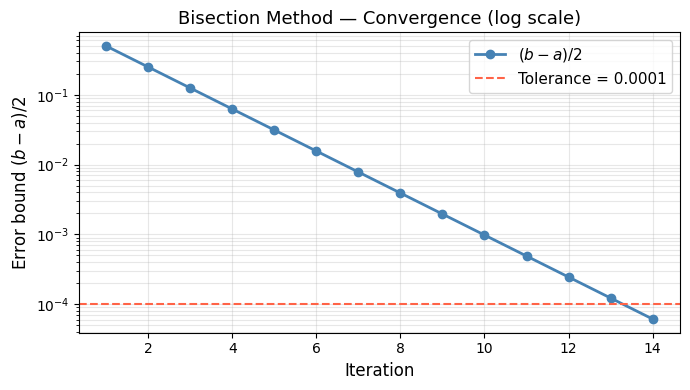

Notice: the error bound halves at every step — this is LINEAR convergence.
On a log scale, this appears as a straight line.


In [ ]:
iters      = [row[0] for row in history]
half_widths = [row[5] for row in history]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(iters, half_widths, 'o-', color='steelblue', linewidth=2, markersize=6, label='$(b-a)/2$')
ax.axhline(TOL, color='tomato', linewidth=1.5, linestyle='--', label=f'Tolerance = {TOL}')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Error bound $(b-a)/2$', fontsize=12)
ax.set_title('Bisection Method — Convergence (log scale)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: the error bound halves at every step — this is LINEAR convergence.")
print("On a log scale, this appears as a straight line.")

---
## Exercises

1. **Change the function.** Try $f(x) = \cos(x) - x$ on $[0, 1]$. What root do you find?

2. **Change the tolerance.** Set `TOL = 1e-8` and count how many more iterations are needed.
   Can you predict the number using the formula $n \geq \log_2\!\left(\frac{b-a}{\text{TOL}}\right)$?

3. **What if the interval is wrong?** Remove the `assert` check and try `a = 0, b = 1`
   for the original $f$. What happens?

4. **Count the halvings.** The error bound after $n$ steps is $(b-a)/2^n$.
   Verify this against your convergence table.